<a href="https://colab.research.google.com/github/jeffheaton/app_deep_learning/blob/main/t81_558_class_11_3_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T81-558: Applications of Deep Neural Networks
**Module 11: Troubleshooting and Evaluating PyTorch Models**  

* Instructor: [Jeff Heaton](https://sites.washu.edu/jeffheaton/), McKelvey School of Engineering, [Washington University in St. Louis](https://engineering.washu.edu/index.html)
* For more information visit the [class website](https://sites.washu.edu/jeffheaton/t81-558/).

# Module 11 Material

* Part 11.1: Debugging with PyTorch Networks [[Notebook]](t81_558_class_11_1_debugging_pytorch.ipynb)
* Part 11.2: Critical PyTorch Errors [[Notebook]](t81_558_class_11_2_critical_errors.ipynb)
* **Part 11.3: Overfitting and Underfitting** [[Notebook]](t81_558_class_11_3_overfitting.ipynb)
* Part 11.4: Vanishing and Exploding Gradients [[Notebook]](t81_558_class_11_4_gradients.ipynb)
* Part 11.5: Error Metrics Beyond Accuracy [[Notebook]](t81_558_class_11_5_metrics.ipynb)

# Google CoLab Instructions

The following code checks that Google CoLab is running and sets up the correct hardware settings for PyTorch.

In [1]:
try:
    import google.colab
    COLAB = True
    print("Note: using Google CoLab")
except:
    print("Note: not using Google CoLab")
    COLAB = False

# Make use of a GPU or MPS (Apple) if one is available.  (see module 2.5)
import torch
has_mps = torch.backends.mps.is_built()
device = "mps" if has_mps else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Note: not using Google CoLab


Using device: mps


# Part 11.3: Overfitting and Underfitting

Every supervised model sits somewhere on a spectrum between two failure modes. At one end is **underfitting**, where the model is too simple to capture the pattern in the data and performs poorly even on the examples it was trained on. At the other end is **overfitting**, where the model is so flexible that it memorizes the training data, including its noise, and fails to generalize to new examples it has never seen. The art of training a good model is finding the middle ground between these extremes.

What makes this difficult is that the training loss alone cannot tell the two apart from success. A low training loss might mean the model has learned the real pattern, or it might mean the model has memorized the training set. The only way to know which is to measure performance on data the model did not train on: a held-out validation set. The relationship between training performance and validation performance is the single most informative signal about where a model sits on the underfitting-overfitting spectrum.

This section shows how to read that signal. We will train the same architecture at three different capacities on a small, deliberately noisy dataset, record the training and validation loss at every epoch, and plot the resulting learning curves. The three curves make the difference between underfitting, a good fit, and overfitting visible at a glance, and the shapes you see here are the same ones you will learn to recognize in your own projects.

## The Bias-Variance Tradeoff

The tension between underfitting and overfitting is often described as the **bias-variance tradeoff**. A model with high *bias* makes strong assumptions that limit what it can represent; it underfits, missing real structure in the data. A model with high *variance* is so sensitive that it changes dramatically with small changes in the training data; it overfits, chasing noise instead of signal. Model capacity, the number of parameters and the flexibility of the architecture, moves a model along this axis. Too little capacity produces bias; too much, left unchecked, produces variance.

The practical way to diagnose where a model sits is to compare two numbers: its error on the training set and its error on a validation set.

* **Underfitting:** both training and validation error are high. The model cannot even fit the data it has seen, so adding regularization or more data will not help. The remedy is *more* capacity or better features.
* **A good fit:** both errors are low and close to each other. The model has captured the underlying pattern and generalizes to new data.
* **Overfitting:** training error is low but validation error is high, and the gap between them is large. The model has memorized the training set. The remedy is *less* effective capacity, through regularization, more data, or early stopping.

The key insight is that the *gap* between training and validation error measures overfitting, while the *level* of the training error measures underfitting. Reading both together tells you which direction to move.

## Building the Experiment

To make these regimes concrete we use `make_moons`, a two-dimensional dataset of two interleaving half-circles, with a high noise level so that memorizing individual points is clearly different from learning the underlying shape. We split it evenly into training and validation halves. A small, noisy dataset like this makes overfitting easy to induce and easy to see.

The `train_model` function below builds a simple fully connected classifier of a chosen width, trains it for a fixed number of epochs, and, crucially, records both the training loss and the validation loss after every epoch. Returning this history is what lets us plot learning curves afterward. Notice that the validation loss is computed inside `torch.no_grad()` and with the model in `eval()` mode, so that measuring performance never affects the parameters.

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

torch.manual_seed(0)
np.random.seed(0)

# A small, noisy dataset makes over- and underfitting easy to see.
X_np, y_np = make_moons(n_samples=200, noise=0.35, random_state=0)
X_tr, X_va, y_tr, y_va = train_test_split(
    X_np, y_np, test_size=0.5, random_state=0)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
X_va = torch.tensor(X_va, dtype=torch.float32)
y_va = torch.tensor(y_va, dtype=torch.long)


def train_model(hidden, epochs=400, weight_decay=0.0):
    torch.manual_seed(0)
    model = nn.Sequential(
        nn.Linear(2, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, 2),
    )
    opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    history = {"train": [], "val": []}
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        train_loss = loss_fn(model(X_tr), y_tr)
        train_loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_va), y_va)

        history["train"].append(train_loss.item())
        history["val"].append(val_loss.item())
    return history


# Three regimes of the same architecture.
underfit = train_model(hidden=1, epochs=400)                       # too little capacity
good_fit = train_model(hidden=16, epochs=400, weight_decay=1e-2)   # capacity + regularization
overfit  = train_model(hidden=256, epochs=400)                     # high capacity, no regularization

print("Training complete for all three models.")

Training complete for all three models.


## Reading the Learning Curves

With the histories recorded, we plot training and validation loss against the epoch number for each of the three models. Learning curves are the standard diagnostic tool for overfitting and underfitting, and learning to read their shape is a skill that transfers to every model you will build. Watch two things in each panel: how *low* the curves get, which reflects capacity, and how *far apart* the training and validation curves drift, which reflects overfitting.

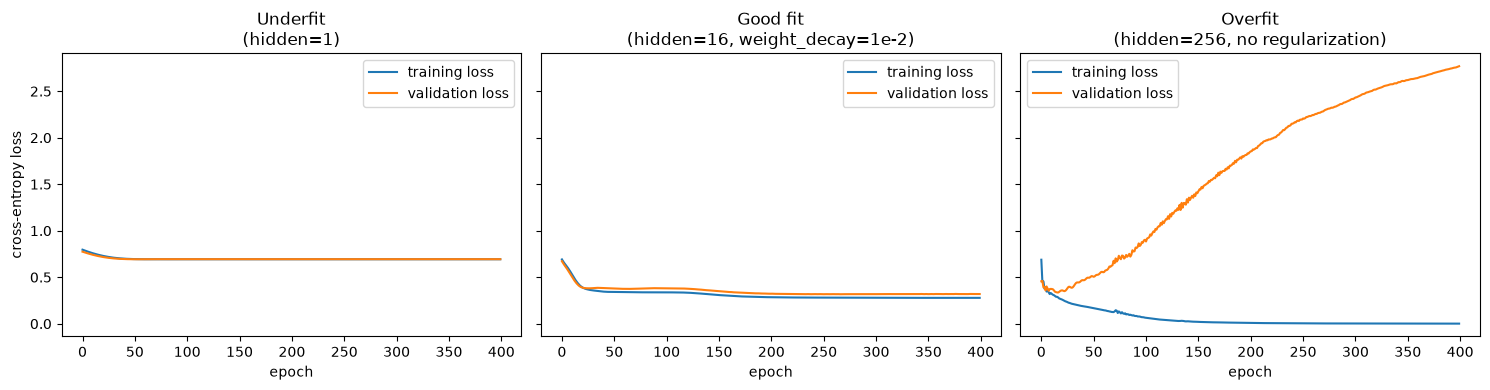

Final losses:
  Underfit  train 0.693   val 0.694   gap +0.001
  Good fit  train 0.278   val 0.319   gap +0.041
  Overfit   train 0.001   val 2.769   gap +2.768


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

panels = [
    ("Underfit\n(hidden=1)", underfit),
    ("Good fit\n(hidden=16, weight_decay=1e-2)", good_fit),
    ("Overfit\n(hidden=256, no regularization)", overfit),
]

for ax, (title, hist) in zip(axes, panels):
    ax.plot(hist["train"], label="training loss")
    ax.plot(hist["val"], label="validation loss")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.legend()

axes[0].set_ylabel("cross-entropy loss")
plt.tight_layout()
plt.show()

print("Final losses:")
for title, hist in [("Underfit", underfit), ("Good fit", good_fit), ("Overfit", overfit)]:
    print(f"  {title:9s} train {hist['train'][-1]:.3f}   val {hist['val'][-1]:.3f}"
          f"   gap {hist['val'][-1] - hist['train'][-1]:+.3f}")

Each panel tells a different story. In the **underfit** model, with a single hidden unit, both curves stay high and never separate: the network lacks the capacity to represent the two moons, so it fits neither the training nor the validation data well. This is the signature of high bias, and the gap between the curves is small because the model is too rigid to memorize anything.

In the **good fit** model, moderate capacity combined with weight decay drives both losses low and keeps them close together. The small gap between training and validation loss means the model has learned the genuine pattern and generalizes to the held-out half of the data.

In the **overfit** model, the large network with no regularization pushes the training loss very low while the validation loss stops improving and often begins to rise. The widening gap between the two curves is the classic visual signature of overfitting: the model is steadily getting better at the training data while getting worse at everything else. The printed gap column makes this quantitative, with the overfit model showing by far the largest divergence.

## Remedies

Once a learning curve tells you which regime you are in, the response follows directly. If the model is **underfitting**, both losses are high and the fix is to increase effective capacity: add layers or width, train longer, engineer better features, or reduce regularization that is holding the model back.

If the model is **overfitting**, the training loss is low but the gap to validation is wide, and the fix is to reduce effective capacity or supply more information:

* **More data** is the most reliable cure; a larger, more varied training set is harder to memorize and forces the model to learn general structure. Data augmentation, covered in Module 5, is a way to manufacture more effective data.
* **Regularization** such as the weight decay used above, or dropout from [Module 4.5](t81_558_class_04_5_dropout.ipynb), penalizes complexity and discourages memorization.
* **Early stopping**, covered in [Module 4.2](t81_558_class_04_2_early_stop.ipynb), halts training at the point where validation loss is lowest, before the overfitting gap has a chance to widen. On the overfit curve above, the ideal stopping point is the epoch where the validation loss bottoms out.
* **Reducing model size** directly lowers capacity when a network is simply larger than the problem requires.

The broader lesson is that overfitting and underfitting are not bugs to be eliminated but a balance to be tuned, and the learning curve is the instrument that tells you which way to turn. Two specific mechanisms that can distort this balance during training, gradients that vanish or explode, are the subject of the next section, [Vanishing and Exploding Gradients](t81_558_class_11_4_gradients.ipynb).